# Comparación de Modelos Númericos con puntos alazar

A continución, se muestra las graficas de curvas de nivel donde se observa la trayectoria obtenida por cada método.

NOTA:
-  Las funciones y los modelos fueron implementados como modulos individuales para poder ser invocados desde el notebook

## Importación de Dependencias y Generación de puntos aleatorios

In [101]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
%autoreload 2

In [103]:
# Dependencias

import numpy as np
import random
from config.logging import setUpLogging
from graph.graph_foo import FunctionPlotter2D
from numerical_methods.gradient_descent import MDG_Wolfe
from numerical_methods.newton import NewtonMethod
from numerical_methods.max_decrease import MDG_DM
from functions.sphere_foo import SphereFunction
from functions.mcCormick_foo import McCormickFunction
from functions.dixon_price_foo import DixonPriceFunction
from functions.easom_foo import EasomFunction
from functions.rastrigin_foo import RastriginFunction
from utils.aux_functions import getTestValues, mergeLists, crear_tabla_comparativa, resumen_tabla
from graph.graph_foo import FunctionPlotter2D
import logging

setUpLogging()
logger = logging.getLogger(__name__)

# Cantidad de puntos
n_points = 1

# Variables
n_var = 2

# Función Esfera con 10 variables
sphere = SphereFunction()
test_data_sphere: np.array = getTestValues(n_points, n_var, sphere.domain[0], sphere.domain[1])
print("Sphere Test Data: ", test_data_sphere)


# Función McCormick con 2 variables
mcCormick = McCormickFunction()

test_data_mcCormick_x0: np.array = getTestValues(n_points, 1, mcCormick.domain[0], mcCormick.domain[1])
test_data_mcCormick_x1: np.array = getTestValues(n_points, 1, mcCormick.domain_x2[0], mcCormick.domain_x2[1])
test_data_mcCormick: np.array[tuple] = mergeLists(test_data_mcCormick_x0, test_data_mcCormick_x1)
print("McCormick Test Data: ",test_data_mcCormick)

# Función de Dixon-Price con 4 variables
dixon_price = DixonPriceFunction()

test_data_dixon_price: np.array = getTestValues(n_points, n_var, -100, 100)
print("Dixon-Price Test Data: ", test_data_dixon_price)

# Función de Easom con 2 variables
easom = EasomFunction()

test_data_easom: np.array = getTestValues(n_points, 2, easom.domain[0], easom.domain[1])
print("Easom Test Data: ", test_data_easom)

# Función de Rastrigin con 5 variables
rastrigin = RastriginFunction()

test_data_rastrigin: np.array = getTestValues(n_points, 5, rastrigin.domain[0], rastrigin.domain[1])
print("Rastrigin Test Data: ", test_data_rastrigin)



Sphere Test Data:  [[-0.80150244 -3.05348168]]
McCormick Test Data:  [[1.06100215 3.35462379]]
Dixon-Price Test Data:  [[-5.30027814 55.31407054]]
Easom Test Data:  [[-2.16598462  6.18571783]]
Rastrigin Test Data:  [[ 1.05538951  3.65465766  4.65944817 -3.95629449 -2.51943665]]


# Curvas de Nivel y Trayectoria: Función Esfera

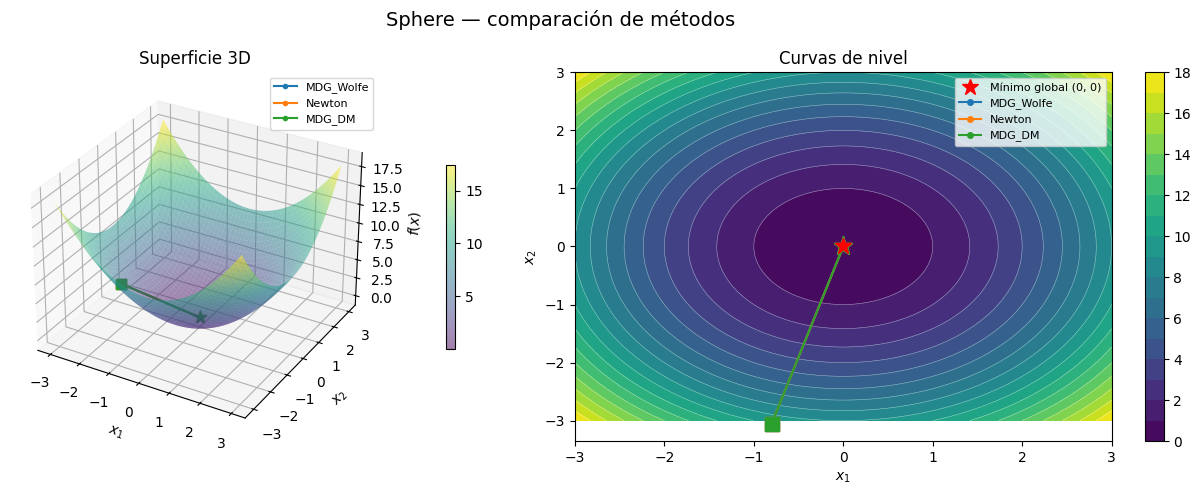

In [104]:

n_iter = 20
for i, test in enumerate(test_data_sphere):

    x_opt_1, trayectoria_1 = MDG_Wolfe(
        f        = sphere.f,
        Df       = sphere.Df,
        x0       = test,
        c1       = 1e-4,    # qué tan estricto es el descenso (Armijo)
        c2       = 0.9,     # qué tan estricta es la curvatura
        alph_max = 1.0,     # paso máximo que puede probar la búsqueda
        max_iter = n_iter
    )


    x_opt_2, trayectoria_2 = NewtonMethod(
        G=sphere.Df,
        H=sphere.H,
        x0=test,
        max_iter=n_iter
    )


    x_opt_3, trayectoria_3 = MDG_DM(
        f=sphere.f,
        Df=sphere.Df,
        x0=test,
        max_iter=n_iter
    )

    plotter = FunctionPlotter2D(lim=3.0)

    plotter.plot_trayectorias(
        f=sphere.f,
        trayectorias={
            "MDG_Wolfe" : trayectoria_1,
            "Newton"    : trayectoria_2,
            "MDG_DM"    : trayectoria_3,
        },
        title="Sphere — comparación de métodos",
        minimo=(0, 0)
    )





# Curvas de Nivel y Trayectoria: Función McCormick

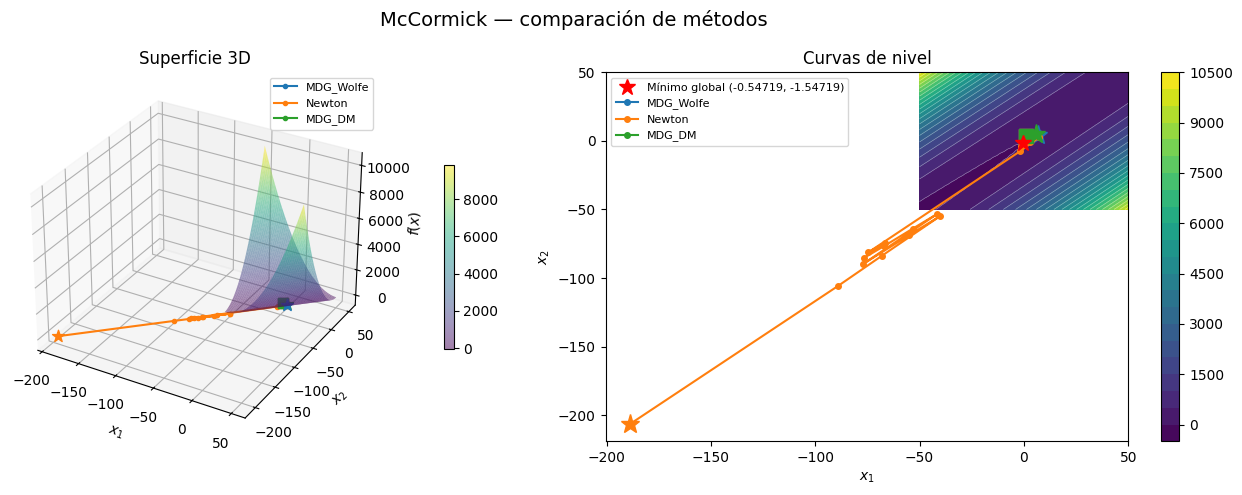

In [105]:

n_iter = 20
for i, test in enumerate(test_data_mcCormick):

    x_opt_1, trayectoria_1 = MDG_Wolfe(
        f        = mcCormick.f,
        Df       = mcCormick.Df,
        x0       = test,
        c1       = 1e-4,    # qué tan estricto es el descenso (Armijo)
        c2       = 0.9,     # qué tan estricta es la curvatura
        alph_max = 1.0,     # paso máximo que puede probar la búsqueda
        max_iter = n_iter
    )

    x_opt_2, trayectoria_2 = NewtonMethod(
        G=mcCormick.Df,
        H=mcCormick.H,
        x0=test,
        max_iter=n_iter
    )

    x_opt_3, trayectoria_3 = MDG_DM(
        f=mcCormick.f,
        Df=mcCormick.Df,
        x0=test,
        max_iter=n_iter
    )

    plotter = FunctionPlotter2D(lim=50.0)

    plotter.plot_trayectorias(
        f=mcCormick.f,
        trayectorias={
            "MDG_Wolfe" : trayectoria_1,
            "Newton"    : trayectoria_2,
            "MDG_DM"    : trayectoria_3,
        },
        title="McCormick — comparación de métodos",
        minimo=(-0.54719, -1.54719)
    )



# Curvas de Nivel y Trayectoria: Función de Dixon-Price

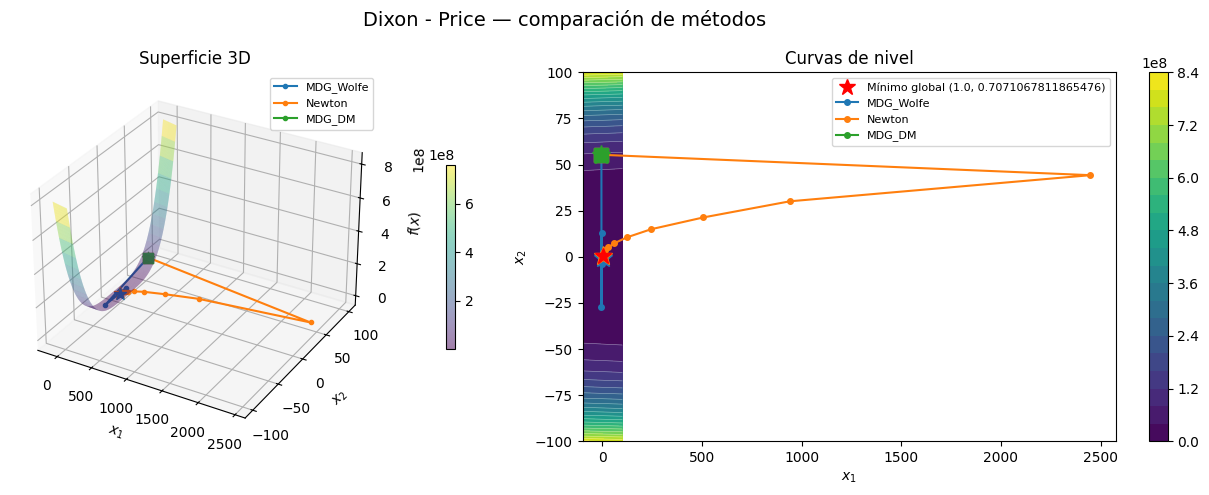

In [106]:

n_iter = 20
for i, test in enumerate(test_data_dixon_price):

    x_opt_1, trayectoria_1 = MDG_Wolfe(
        f        = dixon_price.f,
        Df       = dixon_price.Df,
        x0       = test,
        c1       = 1e-4,    # qué tan estricto es el descenso (Armijo)
        c2       = 0.9,     # qué tan estricta es la curvatura
        alph_max = 1.0,     # paso máximo que puede probar la búsqueda
        max_iter = n_iter
    )

    x_opt_2, trayectoria_2 = NewtonMethod(
        G=dixon_price.Df,
        H=dixon_price.H,
        x0=test,
        max_iter=n_iter
    )

    x_opt_3, trayectoria_3 = MDG_DM(
        f=dixon_price.f,
        Df=dixon_price.Df,
        x0=test,
        max_iter=n_iter
    )


    plotter = FunctionPlotter2D(lim=100.0)

    plotter.plot_trayectorias(
        f=dixon_price.f,
        trayectorias={
            "MDG_Wolfe" : trayectoria_1,
            "Newton"    : trayectoria_2,
            "MDG_DM"    : trayectoria_3,
        },
        title="Dixon - Price — comparación de métodos",
        minimo=(dixon_price.global_min[0], dixon_price.global_min[1])
    )


# Curvas de Nivel y Trayectoria: Función de Easom

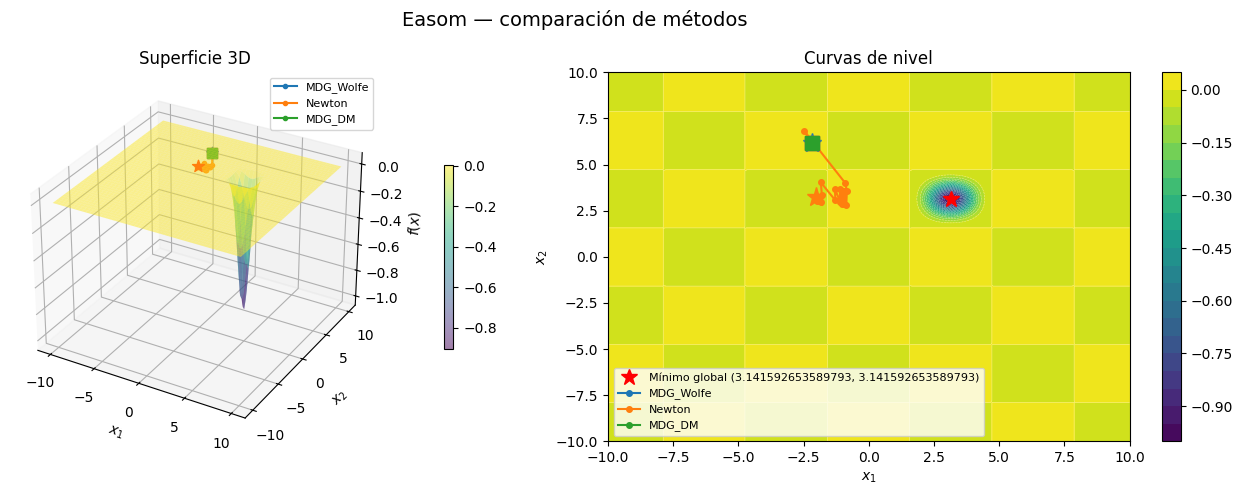

In [107]:


n_iter = 20
for i, test in enumerate(test_data_easom):

    x_opt_1, trayectoria_1 = MDG_Wolfe(
        f        = easom.f,
        Df       = easom.Df,
        x0       = test,
        c1       = 1e-4,    # qué tan estricto es el descenso (Armijo)
        c2       = 0.9,     # qué tan estricta es la curvatura
        alph_max = 1.0,     # paso máximo que puede probar la búsqueda
        max_iter = n_iter
    )

    x_opt_2, trayectoria_2 = NewtonMethod(
        G=easom.Df,
        H=easom.H,
        x0=test,
        max_iter=n_iter
    )

    x_opt_3, trayectoria_3 = MDG_DM(
        f=easom.f,
        Df=easom.Df,
        x0=test,
        max_iter=n_iter
    )

    plotter = FunctionPlotter2D(lim=10.0)

    plotter.plot_trayectorias(
        f=easom.f,
        trayectorias={
            "MDG_Wolfe" : trayectoria_1,
            "Newton"    : trayectoria_2,
            "MDG_DM"    : trayectoria_3,
        },
        title="Easom — comparación de métodos",
        minimo=easom.global_min
    )


# Curvas de Nivel y Trayectoria: Función de Rastrigin

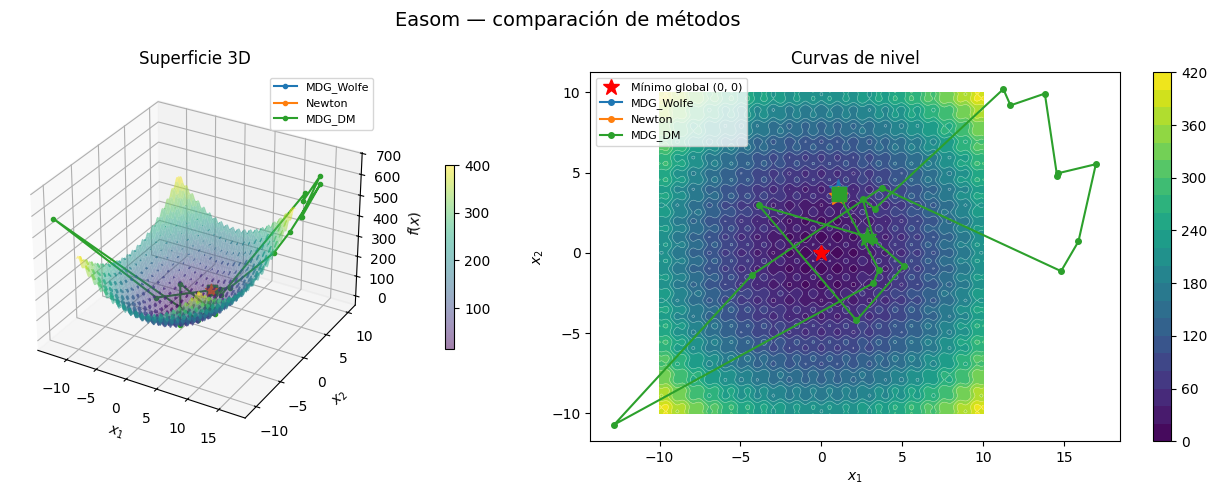

In [108]:

n_iter = 20
for i, test in enumerate(test_data_rastrigin):

    x_opt_1, trayectoria_1 = MDG_Wolfe(
        f        = rastrigin.f,
        Df       = rastrigin.Df,
        x0       = test,
        c1       = 1e-4,    # qué tan estricto es el descenso (Armijo)
        c2       = 0.9,     # qué tan estricta es la curvatura
        alph_max = 1.0,     # paso máximo que puede probar la búsqueda
        max_iter = n_iter
    )

    x_opt_2, trayectoria_2 = NewtonMethod(
        G=rastrigin.Df,
        H=rastrigin.H,
        x0=test,
        max_iter=n_iter
    )

    x_opt_3, trayectoria_3 = MDG_DM(
        f=rastrigin.f,
        Df=rastrigin.Df,
        x0=test,
        max_iter=n_iter
    )


    plotter = FunctionPlotter2D(lim=10.0)

    plotter.plot_trayectorias(
        f=rastrigin.f,
        trayectorias={
            "MDG_Wolfe" : trayectoria_1,
            "Newton"    : trayectoria_2,
            "MDG_DM"    : trayectoria_3,
        },
        title="Easom — comparación de métodos",
        minimo=(0, 0)
    )

